In [1]:
# Imports
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load data
df = pd.read_csv("../data/il_cost_breakdown.csv")

/var/folders/sr/hy8nzjhj7xz25lt74m44nv140000gn/T/ipykernel_89592/3201102921.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_labels, fontsize=12, fontfamily='Cabin')


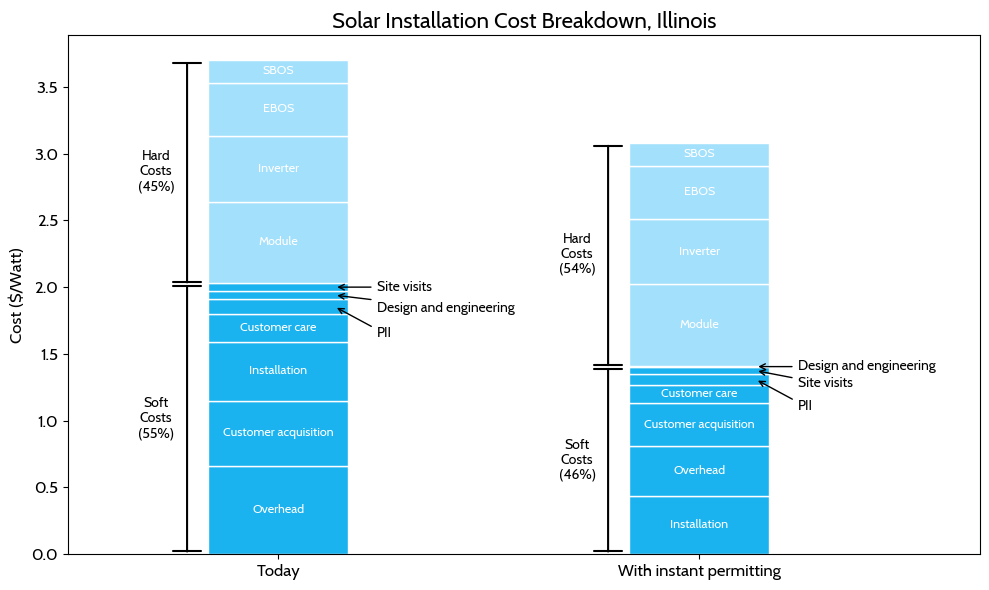

In [65]:
# ensure soft always stacks below hard
df = df.copy()
df['type_order'] = df['type'].map({'soft': 0, 'hard': 1})

# plot setup
fig, ax = plt.subplots(figsize=(10, 6))
scenarios = ['baseline', 'policy']
x_positions = [-.25, 1.25]
x_labels = ['Today', 'With instant permitting']
y_labels = lst = [str(i * 0.5) for i in range(0, int(3.5/0.5) + 1)]
bar_width = 0.5
threshold = 0.04  # 5% threshold for inline labels

for x, scenario, xlabel in zip(x_positions, scenarios, x_labels):
    sub = df[df['scenario']==scenario] \
            .sort_values(['type_order','value'], ascending=[True, False])
    total = sub['value'].sum()
    bottom = 0
    small_counter = 0

    # draw each slice
    for _, row in sub.iterrows():
        h = row['value']
        col = '#1bb3ef' if row['type']=='soft' else '#a2e0fc'
        ax.bar(x, h, bottom=bottom, width=bar_width, color=col, edgecolor='white')

        yc = bottom + h/2
        frac = h/total

        if frac >= threshold:
            # big enough: label inside
            ax.text(x, yc, row['label'], ha='center', va='center',
                    color='white', fontsize=9, fontfamily='Cabin')
        else:
            # small slice: arrow call‐out, staggered vertically so they don't cross
            tx = x + bar_width
            ty = yc + small_counter * 0.1
            ax.annotate(
                row['label'],
                xy=(x+.2, yc),
                xytext=(tx-.15, ty-.2),
                textcoords='data',
                ha='left', va='center',
                arrowprops=dict(arrowstyle='->', lw=1, color='k'),
                fontfamily='Cabin'
            )
            small_counter += 1

        bottom += h

    # add brackets + percentage labels
    soft_tot = sub.loc[sub['type']=='soft','value'].sum()
    hard_tot = sub.loc[sub['type']=='hard','value'].sum()
    soft_pct = soft_tot/total * 100
    hard_pct = hard_tot/total * 100
    bx = x - bar_width/2 - 0.075

    # Soft bracket
    ax.annotate(
        '',
        xy=(bx, 0),
        xytext=(bx, soft_tot-.0015),
        arrowprops=dict(arrowstyle='|-|', lw=1.5, color='black'),
        fontfamily='Cabin'
    )
    ax.text(
        bx-.11, soft_tot/2,
        f"Soft\nCosts\n({soft_pct:.0f}%)",
        ha='center', va='center', fontsize=10,
        fontfamily='Cabin'
    )

    # Hard bracket
    ax.annotate(
        '',
        xy=(bx, soft_tot-.015),
        xytext=(bx, soft_tot+hard_tot-.0015),
        arrowprops=dict(arrowstyle='|-|', lw=1.5, color='black'),
        fontfamily='Cabin'
    )
    ax.text(
        bx-.11, soft_tot + hard_tot/2,
        f"Hard\nCosts\n({hard_pct:.0f}%)",
        ha='center', va='center', fontsize=10,
        fontfamily='Cabin'
    )

# finalize styling
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=12, fontfamily='Cabin')
ax.set_yticklabels(y_labels, fontsize=12, fontfamily='Cabin')
ax.set_xlim(-1, 2.25)
ax.set_ylabel('Cost ($/Watt)', fontsize=12, fontfamily='Cabin')
ax.set_title('Solar Installation Cost Breakdown, Illinois', fontsize=16, fontfamily='Cabin')
plt.tight_layout()
plt.show()

In [31]:
df.groupby(['scenario', 'type']).agg({'value': 'sum'}).reset_index()

,scenario,type,value
0,baseline,hard,1.67
1,baseline,soft,2.03
2,policy,hard,1.67
3,policy,soft,1.41
